# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')

In [2]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [3]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [4]:
daily_count = df['count'].resample('D').sum()
daily_count

datetime
2011-01-01     985
2011-01-02     801
2011-01-03    1349
2011-01-04    1562
2011-01-05    1600
              ... 
2012-12-15    5047
2012-12-16    3786
2012-12-17    4585
2012-12-18    5557
2012-12-19    5267
Freq: D, Name: count, Length: 719, dtype: int64

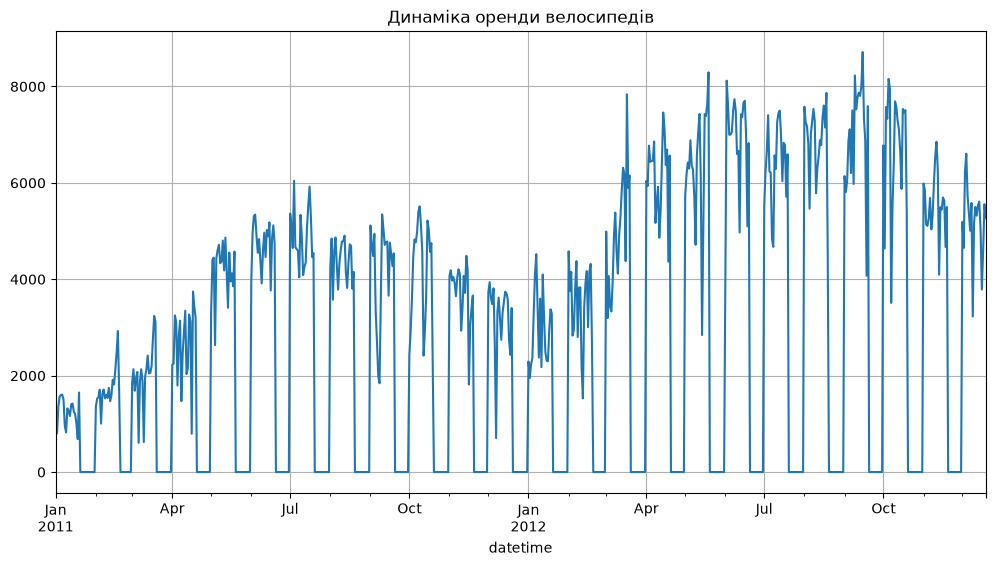

In [5]:
daily_count.plot(figsize=(12,6),
    title="Динаміка оренди велосипедів",
    grid=True
    )

plt.show()

In [6]:
df.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'date', 'day',
       'week', 'weekday_num', 'weekday', 'year', 'month', 'hour'],
      dtype='str')

Графік має заломи кожного місяця і причиною того, є відсутність частини даних в місяці (після 19 числа кожного місяця дані відсутні
для перевірки цієї версії відобразимо останні 2 строки данмх за січень 2011 року (див. нижче)

На графіку спостерігається загальна тенденція росту кількості орендованих велосипедів в 2012 році порівняно з 2011 роком.
Також прослідковується сезонність: з червня по жовтень орендують велосипеди більше, а в інші місяці - менше.

Аномально низькі значення можуть бути пов'язані з поганими погодними умовами (дуже сильний вітер, злива, гроза, град і тп)
їх на графіку можна побачити у вересні, жовтні та грудні 2011, та лютому, травні, вересні та жовтні 2012.

Аномально високі значення можуть бути пов'язані з гарною погодою і початком сезону (як в кінці березня 2012 наприклад, а також можуть бути зумовлені результатом рекламних кампаній і акцій.


In [7]:
df.query('month == 1  & year==2011').tail(2)  #останній день даних


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-19 22:00:00,1,0,1,1,12.3,15.150,52,11.0014,6,53,59,2011-01-19,19,3,2,Wednesday,2011,1,22
2011-01-19 23:00:00,1,0,1,1,12.3,13.635,52,31.0009,1,27,28,2011-01-19,19,3,2,Wednesday,2011,1,23


In [8]:
df.query('month == 3  & year==2012').groupby(['day'])['count'].sum() #пік користувачів є 17.03.2012

day
1     4990
2     3194
3     4066
4     3423
5     3333
6     3956
7     4916
8     5382
9     4569
10    4118
11    4911
12    5298
13    5847
14    6312
15    6192
16    4378
17    7836
18    5892
19    6153
Name: count, dtype: int64

In [9]:
count_by_usertype = pd.pivot_table(df.query('month == 3 & day > 13 & year==2012'), index='day', values=('casual','registered'), aggfunc='sum')
print(count_by_usertype)  # 17 березня пік був за рахунок не зареєстрованих користувачів, що може бути результатом рекламної кампанії

     casual  registered
day                    
14      997        5315
15     1005        5187
16      548        3830
17     3155        4681
18     2207        3685
19      982        5171



## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [10]:
def local_quarter_id(month):
    if month <= 2 or month == 12:
        return  'winter'
    if month <= 5:
        return 'summer'
    if month <= 9:
        return 'monsoon'
    else:
        return 'post-monsoon'

df['weather_season_india'] =  df.month.apply(local_quarter_id)
df[:2]


,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour,weather_season_india
datetime,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0,winter
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1,winter


In [11]:
season_order = ['winter', 'summer', 'monsoon', 'post-monsoon']
df['weather_season_india'] = pd.Categorical(df['weather_season_india'], categories=season_order, ordered=True)


In [12]:
av_rents = df.groupby(['weather_season_india'])['count'].mean()
print(av_rents)

weather_season_india
winter          125.753430
summer          184.074210
monsoon         236.322359
post-monsoon    210.688255
Name: count, dtype: float64


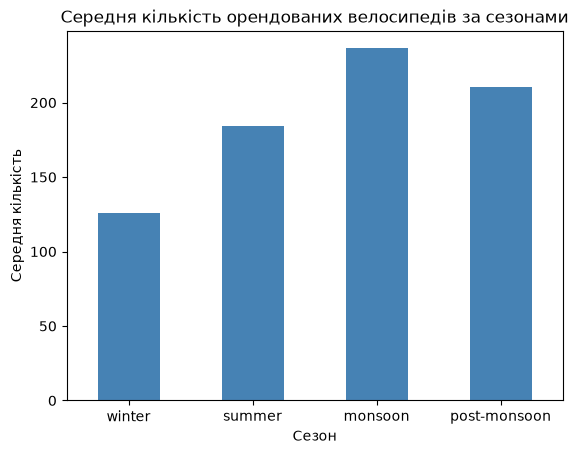

In [13]:
ax = av_rents.plot.bar(
    title='Середня кількість орендованих велосипедів за сезонами',
    xlabel='Сезон',
    ylabel='Середня кількість',
    color='steelblue',
    rot=0
)

plt.show()

In [14]:
count_weathertype = pd.pivot_table(df, index='weather_season_india', columns='weather', values='count', aggfunc='mean')
print(count_weathertype)  # середня кількість оренди велосипедів по погодним сезонам та погодою

weather                        1           2           3      4
weather_season_india                                           
winter                130.758397  129.496815   72.154206  164.0
summer                206.619521  160.646452   97.555085    NaN
monsoon               245.145921  232.048469  157.572000    NaN
post-monsoon          222.134697  202.200000  152.402516    NaN


In [15]:
count_weathertype = pd.pivot_table(df, index='weather_season_india', columns='weather', values='temp', aggfunc='mean')
print(count_weathertype)   # середня температура по погодним сезонам та погодою

weather                       1          2          3    4
weather_season_india                                      
winter                11.559246  12.250904  12.625701  8.2
summer                19.057452  19.418658  18.495169  NaN
monsoon               28.660743  27.906148  26.607360  NaN
post-monsoon          17.724024  18.455020  19.318994  NaN



Найбільша середня кількість оренди велосипедів спостерігається в сезон monsoon, а найменша - в сезон winter.
Різниця в середній кількості оренди велосипедів між сезонами monsoon та winter становить приблизно в 2 рази.
сезонна закономірність скоріш за все пов'язана з погодними умовами. 
Коли ясно, то середня кількість оренди велосипедів висока. проте зимою велосипеди орендують в середньому менше, ніж в інші сезони, бо середня температура значно нижча зимою.


## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренд велосипедів на годину по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд у цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


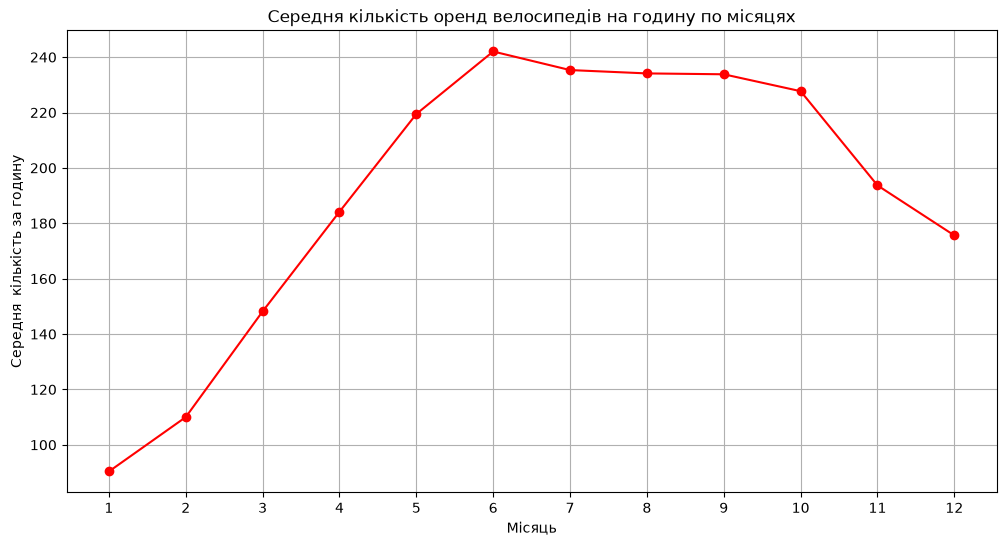

In [16]:
monthly_av_count = df.groupby(['month'])['count'].mean()
monthly_av_count.plot(kind='line',
    figsize=(12,6),
    marker='o',
    color='red',
    title="Середня кількість оренд велосипедів на годину по місяцях",
    grid=True,
    xticks=[1,2,3,4,5,6,7,8,9,10,11,12],
    ylabel='Середня  кількість за годину',
    xlabel='Місяць'
)

plt.show()



Пік оренди спостерігається з черня по вересень місяць, а суттєвий спад починається з листопада і триває всю зиму(грудень-лютий) 
це співпадає з висновками з попереднього завдання
Клімат включає набір погодних факторів і впливає на оренду велосипедів протягом року напряму. Чим краща погода(тепло, без сильного вітру та дощу, наприклад), тим більше шансів, що люди будуть користуватись велосипедами, а не авто, таксі чи громадським транспортом.


## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

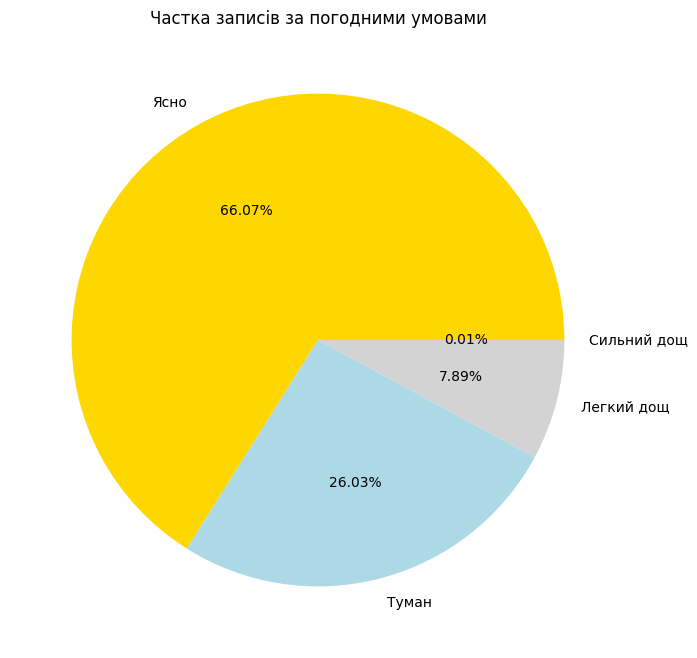

In [17]:
count_by_weather = df.groupby(['weather'])['hour'].count()

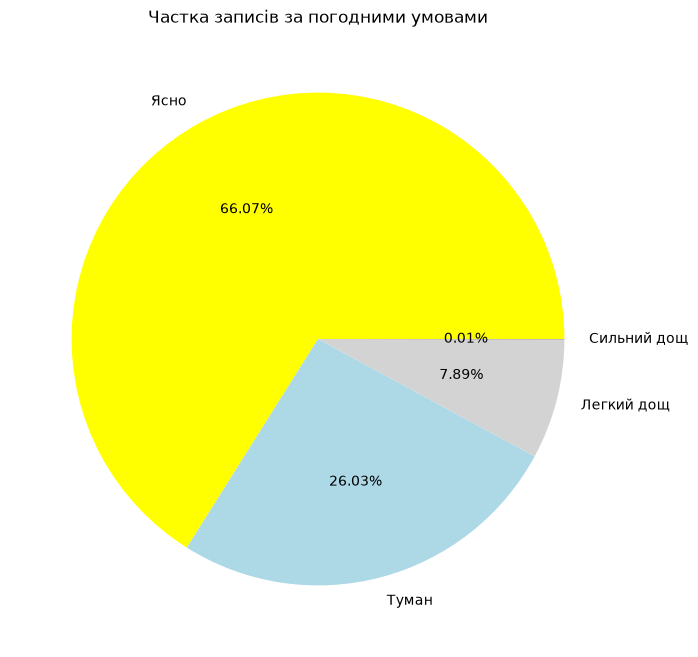

In [18]:
count_by_weather.plot.pie(
    figsize=(8, 8),
    autopct='%1.2f%%',
    labels=['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'],
    title='Частка записів за погодними умовами',
    colors=['yellow','lightblue', 'lightgrey', 'black']
);

Яка погода переважає в датасеті?

в датасеті переважає ясна погода (66.07% всіх записів)

Чи є дні із сильним дощем? Яка їх частка?

дані є, їх частка 0.01% 

Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

так як більша частина записів зроблена в ясну погоду, можна зробити висновок, що орендою велосипедів люди користуються в хороших погодних умовах.
а дощ негативно впливає на оренду, бо частки записів із сильним дошем та легким дощем є маленькими (0.01% та 7.89% відповідно).

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

In [19]:
# додано в датафрейм підписи видів погоди для точності співвідношення цифр і підписів на графіку
weather_map = {
    1: 'Ясно',
    2: 'Туман',
    3: 'Легкий дощ',
    4: 'Сильний дощ'
}
df['weather_name'] = df['weather'].map(weather_map)


In [20]:
# переведено типи погоди в категоріальний тип
weather_order = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']
df['weather_name'] = pd.Categorical(df['weather_name'], categories=weather_order, ordered=True)


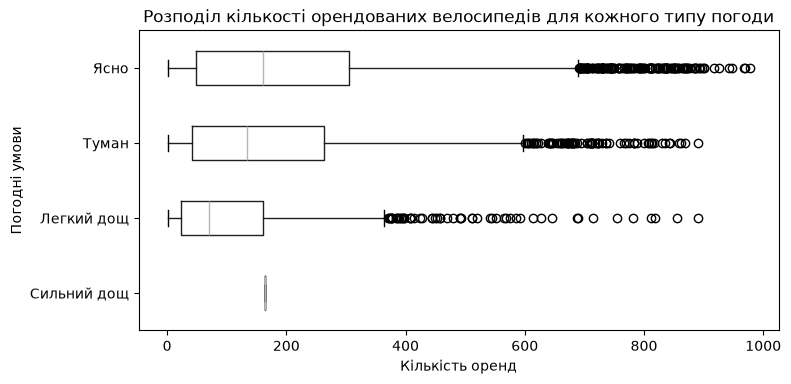

In [21]:
# побудова графіку
ax = df.boxplot(
    column='count',
    by='weather_name',
    figsize=(8, 4),
    vert=False,
     grid = False
)
ax.invert_yaxis() 
plt.title('Розподіл кількості орендованих велосипедів для кожного типу погоди')
plt.suptitle('')  
plt.xlabel('Кількість оренд')
plt.ylabel('Погодні умови')
plt.show()


1. Найбільший розкид у кількості оренди спостерігається при ясній погоді. У неї найбільша коробка(приблизно від 0 до 300), найдовші "вуса" (до 600) та найбільша хмара викидів (до 1000)

2. Так, викиди присутні.
Погода "Ясно" - дуже багато викидів , від 700 до 1000 кількості оренд
Погода "Туман" - теж багато викидів , від 600 до 1000 кількості оренд
Погода "Легкий дощ" - численні викиди, від 370 до 900 кількості оренд
Погода "Сильний дощ" - викидів немає, бо дуже мало даних в цій категорії

3. Погода "Ясно" має найвищу медіану (сіра лінія всередині коробки розташована приблизно на позначці ~170);


## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

In [22]:
df.columns

Index(['season', 'holiday', 'workingday', 'weather', 'temp', 'atemp',
       'humidity', 'windspeed', 'casual', 'registered', 'count', 'date', 'day',
       'week', 'weekday_num', 'weekday', 'year', 'month', 'hour',
       'weather_season_india', 'weather_name'],
      dtype='str')

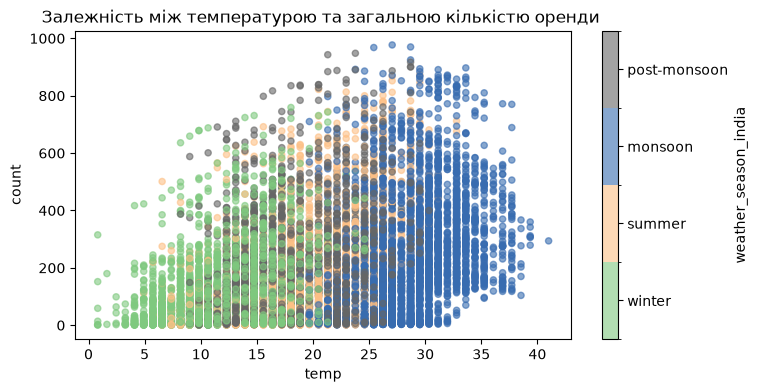

In [51]:
df.plot.scatter(
    x='temp',
    y='count',
    c='weather_season_india',
    colormap="Accent",
    title='Залежність між температурою та загальною кількістю оренди ',
    figsize=(8, 4),
    alpha=0.6
)
plt.show()

Загальний тренд - зростання, але до певної міри.
При низьких температурах (від 0 до 12°C) більшість точок скупчено в нижній частині графіку (до 300 оренд).
Тоді як при температурі від 15 до 33°C кількість оренд суттєво зростає (в діапазоні 500 -1000 оренд) - люди активніше беруть велосипеди в тепліші дні.
Але після ~35°C помітне невелике зниження верхньої межі розкиду — при 35–40°C максимальні значення оренди трохи нижчі (рідко перевищують 700–800), ніж на піку близько 25–30°C. Що видається логічним: за надто високої температури популярність оренди дещо падає.

Розкид кількості оренд також зростає з температурою.
При низьких температурах точки щільно зосереджені внизу (мало оренд, малий розкид). 
У середньому діапазоні температур (15–33°C) розкид значень найбільший — від дуже низьких до дуже високих оренд, що вказує на вплив інших факторів (вихідні/будні, погода, сезон).
При високих температурах (>35°C) розкид значень знову падає (точки розташовані щільніше)

Сезонний залежність виглядає так:

Winter зосереджений при низьких температурах (0–16°C) з низькою кількістю оренд.
Summer та post-monsoon— розташовані у середньому  діапазоні температур до 25 з високою кількістю оренд.
Monsoon домінує при найвищих температурах (25–40°C) з високою кількістю оренд




## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?